# EDA dữ liệu Doc2Table

Notebook này trả lời bốn câu hỏi trước khi đi vào solution:

1. Dataset gồm những gì và có đáng tin cậy để phân tích không?
2. Các difficulty khác nhau ở đâu?
3. Những pattern cấu trúc, nội dung và chất lượng ảnh nào xuất hiện trong dữ liệu?
4. Từ các insight quan sát được, ta sẽ làm gì tiếp theo?

> Notebook chỉ tạo evidence và insight. Phần cuối là khung để điền design direction sau khi chạy; chi tiết thuật toán thuộc notebook solution.

## 0. Chuẩn bị

Mặc định chỉ lấy mẫu một số ảnh ở phần image-quality để notebook chạy nhanh. Đặt `IMAGE_SAMPLE_PER_DIFFICULTY = None` nếu muốn đo toàn bộ ảnh.

In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RANDOM_STATE = 2026
IMAGE_SAMPLE_PER_DIFFICULTY = 80

root_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'Doc2Table']
ROOT = next((path.resolve() for path in root_candidates
             if (path / 'data' / 'training_set' / 'manifest.jsonl').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Không tìm thấy Doc2Table/data. Hãy mở notebook từ Doc2Table/notebooks hoặc thư mục dự án.')

DATA_ROOT = ROOT / 'data'
TRAIN_DIR = DATA_ROOT / 'training_set'

def load_jsonl(path):
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]

records_by_split = {
    split: load_jsonl(DATA_ROOT / split / 'manifest.jsonl')
    for split in ('training_set', 'public_test', 'private_test')
    if (DATA_ROOT / split / 'manifest.jsonl').is_file()
}
train_records = records_by_split['training_set']
print(f'ROOT={ROOT}')
print({split: len(records) for split, records in records_by_split.items()})

ROOT=E:\AIO\Project\olp-ai-ptit-2026-preliminary-round\Doc2Table
{'training_set': 1100, 'public_test': 50, 'private_test': 80}


In [2]:
SEPARATOR = re.compile(r'^:?-{3,}:?$')
BOLD = re.compile(r'^\*\*(.*)\*\*$', re.DOTALL)
MERGE_MARKERS = {'[[H]]', '[[V]]'}

def split_markdown_row(line):
    line = line.strip()
    if not (line.startswith('|') and line.endswith('|')):
        raise ValueError(f'Hàng Markdown không hợp lệ: {line[:80]!r}')
    cells, current, escaped = [], [], False
    for char in line[1:-1]:
        if char == '|' and not escaped:
            cells.append(''.join(current).strip())
            current = []
        else:
            current.append(char)
        escaped = char == '\\' and not escaped
    cells.append(''.join(current).strip())
    return cells

def parse_markdown_tables(text):
    tables, rows = [], []
    for raw_line in text.splitlines():
        line = raw_line.strip()
        if line.startswith('|'):
            row = split_markdown_row(line)
            if not all(SEPARATOR.fullmatch(cell) for cell in row):
                rows.append(row)
        elif not line and rows:
            tables.append(rows)
            rows = []
    if rows:
        tables.append(rows)
    if not tables:
        raise ValueError('Không tìm thấy bảng Markdown')
    for table in tables:
        if len({len(row) for row in table}) != 1:
            raise ValueError('Bảng Markdown không phải ma trận chữ nhật')
    return tables

assert split_markdown_row(r'| a\|b | c |') == [r'a\|b', 'c']
assert parse_markdown_tables('| A | B |\n| --- | --- |\n| x | y |')[0] == [['A', 'B'], ['x', 'y']]

## 2.1 Dataset Overview

### 2.1.1 Data integrity

Kiểm tra file, số trang và khả năng parse label trước khi dùng dữ liệu để suy luận.

In [3]:
integrity_rows = []
seen_ids = Counter(record['id'] for record in train_records)

for record in train_records:
    errors = []
    if seen_ids[record['id']] > 1:
        errors.append('duplicate_id')
    if record['page_count'] != len(record['image_paths']):
        errors.append('page_count_vs_images')
    if record['page_count'] != len(record.get('page_label_paths', [])):
        errors.append('page_count_vs_page_labels')

    paths = [*(TRAIN_DIR / path for path in record['image_paths']),
             TRAIN_DIR / record['label_path'],
             *(TRAIN_DIR / path for path in record.get('page_label_paths', []))]
    if any(not path.is_file() for path in paths):
        errors.append('missing_file')

    if 'missing_file' not in errors:
        try:
            parse_markdown_tables((TRAIN_DIR / record['label_path']).read_text(encoding='utf-8'))
            for path in record.get('page_label_paths', []):
                parse_markdown_tables((TRAIN_DIR / path).read_text(encoding='utf-8'))
        except ValueError:
            errors.append('invalid_markdown')

    integrity_rows.append({'doc_id': record['id'], 'valid': not errors, 'errors': ', '.join(errors)})

integrity_df = pd.DataFrame(integrity_rows)
print(f'Valid documents: {integrity_df.valid.sum():,}/{len(integrity_df):,}')
display(integrity_df.loc[~integrity_df.valid].head(20))

Valid documents: 1,100/1,100


,doc_id,valid,errors


### 2.1.2 Dataset scale and hierarchy

Document, page, table và cell là các đơn vị khác nhau. Các thống kê bên dưới giữ rõ đơn vị để tránh so sánh sai.

In [4]:
split_summary = pd.DataFrame([
    {
        'split': split,
        'documents': len(records),
        'pages': sum(record['page_count'] for record in records),
        'one_page_docs': sum(record['page_count'] == 1 for record in records),
        'two_page_docs': sum(record['page_count'] == 2 for record in records),
        'has_labels': all('label_path' in record for record in records),
        'has_difficulty': all('difficulty' in record for record in records),
    }
    for split, records in records_by_split.items()
])
display(split_summary)

,split,documents,pages,one_page_docs,two_page_docs,has_labels,has_difficulty
0,training_set,1100,1375,825,275,True,True
1,public_test,50,52,48,2,False,False
2,private_test,80,86,74,6,False,False


### 2.1.3 Target representation and evaluation emphasis

Nhãn Extended Markdown chứa năm loại thông tin cần giữ lại:

- text trong cell;
- số bảng, hàng và cột;
- `[[H]]` và `[[V]]` cho merged cells;
- `<br>` cho multiline;
- `**...**` cho bold.

Điểm document gồm **90% TEDS** và **10% Bold-F1**. Đây là mô tả điều được đánh giá, chưa phải quyết định về phương pháp.

## 2.2 Difficulty Levels

### 2.2.1 Distribution and complexity dimensions

,difficulty,documents,pages,tables,median_max_columns,median_max_data_rows
0,M1,325,325,325,5.0,6.0
1,M2,330,366,458,8.0,13.0
2,M3,280,418,528,11.0,14.0
3,M4,165,266,305,13.0,16.0


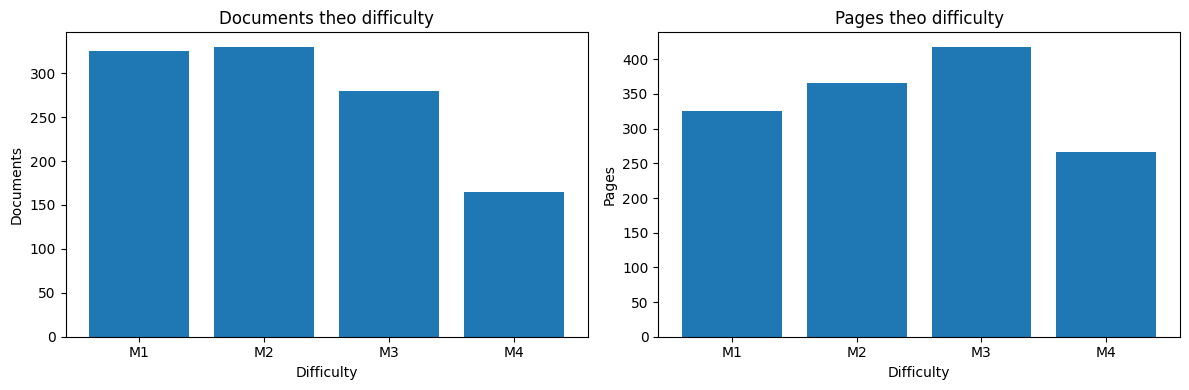

In [5]:
difficulty_summary = (pd.DataFrame([{
    'difficulty': record['difficulty'],
    'pages': record['page_count'],
    'tables': record['attributes']['table_count'],
    'max_columns': record['attributes']['max_columns'],
    'max_data_rows': record['attributes']['max_data_rows'],
} for record in train_records])
.groupby('difficulty')
.agg(documents=('difficulty', 'size'), pages=('pages', 'sum'),
     tables=('tables', 'sum'), median_max_columns=('max_columns', 'median'),
     median_max_data_rows=('max_data_rows', 'median'))
.reset_index())
display(difficulty_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(difficulty_summary.difficulty, difficulty_summary.documents)
axes[0].set(title='Documents theo difficulty', xlabel='Difficulty', ylabel='Documents')
axes[1].bar(difficulty_summary.difficulty, difficulty_summary.pages)
axes[1].set(title='Pages theo difficulty', xlabel='Difficulty', ylabel='Pages')
plt.tight_layout(); plt.show()

,has_merge,has_multiline,has_escaped_pipe,spans_two_pages,long_table_crosses_pages
difficulty,,,,,
M1,0.0%,0.0%,0.0%,0.0%,0.0%
M2,100.0%,100.0%,0.0%,10.9%,10.9%
M3,100.0%,100.0%,100.0%,49.3%,30.4%
M4,100.0%,100.0%,100.0%,61.2%,38.2%


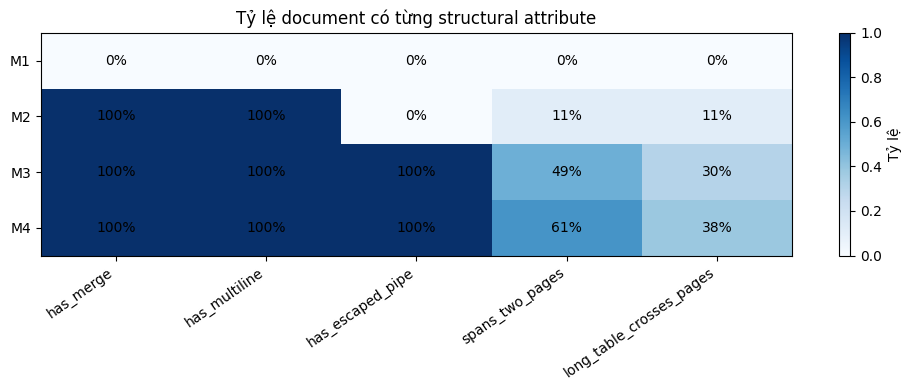

In [6]:
boolean_attributes = [
    'has_merge', 'has_multiline', 'has_escaped_pipe',
    'spans_two_pages', 'long_table_crosses_pages',
]
attribute_rows = [
    {'difficulty': record['difficulty'], **{name: record['attributes'][name] for name in boolean_attributes}}
    for record in train_records
]
attribute_rates = pd.DataFrame(attribute_rows).groupby('difficulty')[boolean_attributes].mean()
display(attribute_rates.style.format('{:.1%}'))

fig, ax = plt.subplots(figsize=(10, 4))
image = ax.imshow(attribute_rates, vmin=0, vmax=1, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(boolean_attributes)), boolean_attributes, rotation=35, ha='right')
ax.set_yticks(range(len(attribute_rates.index)), attribute_rates.index)
for row in range(attribute_rates.shape[0]):
    for col in range(attribute_rates.shape[1]):
        ax.text(col, row, f'{attribute_rates.iloc[row, col]:.0%}', ha='center', va='center')
ax.set_title('Tỷ lệ document có từng structural attribute')
fig.colorbar(image, ax=ax, label='Tỷ lệ')
plt.tight_layout(); plt.show()

### 2.2.2 Ví dụ cho escaped pipe và dữ liệu hai trang

Trong dataset này, `spans_two_pages` tương đương document có `page_count == 2`; hai trang có thể chứa các bảng độc lập. `long_table_crosses_pages` chặt hơn: ít nhất một bảng đang dở ở trang 1 và tiếp tục ở trang 2. Vì vậy thuộc tính thứ hai là trường hợp con của thuộc tính thứ nhất.


has_escaped_pipe: train-00603 | difficulty=M3 | pages=1 | tables=2
{'has_escaped_pipe': True, 'spans_two_pages': False, 'long_table_crosses_pages': False}


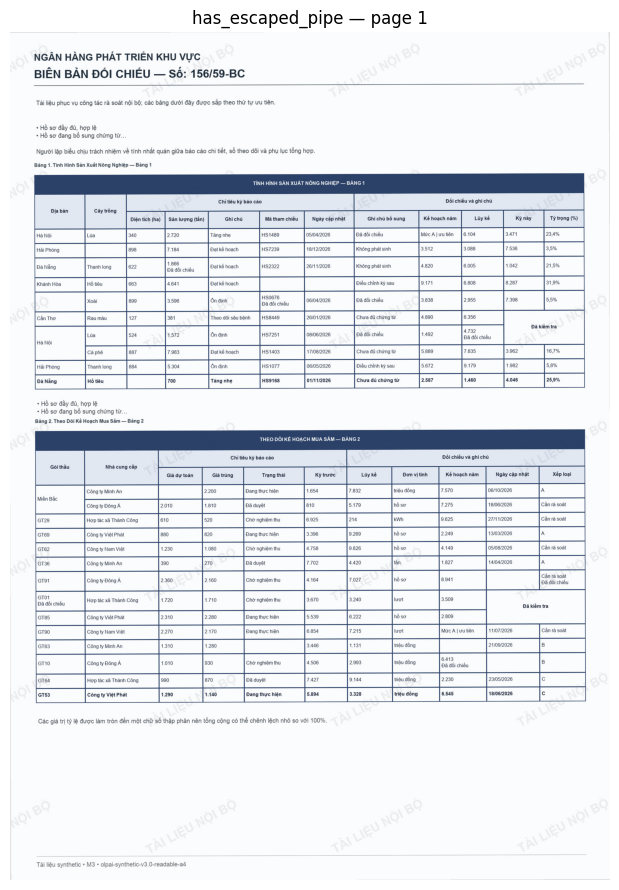

Các dòng chứa escaped pipe:
| Hà Nội | Lúa | 340 | 2.720 | Tăng nhẹ | HS1489 | 05/04/2026 | Đã đối chiếu | Mức A \| ưu tiên | 6.104 | 3.471 | 23,4% |
| GT90 | Công ty Nam Việt | 2.270 | 2.170 | Đang thực hiện | 6.854 | 7.215 | lượt | Mức A \| ưu tiên | 11/07/2026 | Cần rà soát |

spans_two_pages_only: train-00601 | difficulty=M3 | pages=2 | tables=3
{'has_escaped_pipe': True, 'spans_two_pages': True, 'long_table_crosses_pages': False}


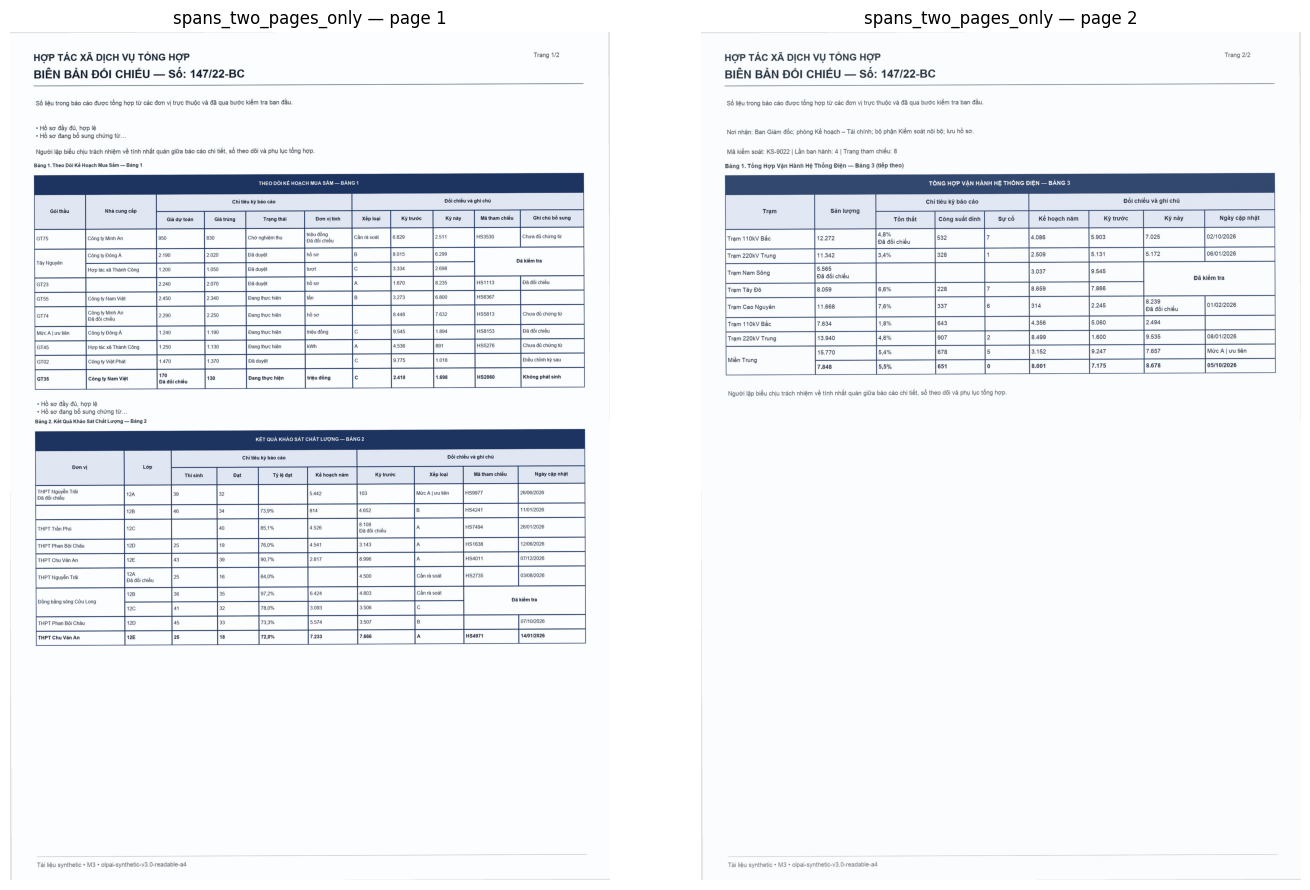


--- Page 1: page_labels/train-00601_p01.md ---
| **THEO DÕI KẾ HOẠCH MUA SẮM — BẢNG 1** | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **Gói thầu** | **Nhà cung cấp** | **Chỉ tiêu kỳ báo cáo** | [[H]] | [[H]] | [[H]] | **Đối chiếu và ghi chú** | [[H]] | [[H]] | [[H]] | [[H]] |
| [[V]] | [[V]] | **Giá dự toán** | **Giá trúng** | **Trạng thái** | **Đơn vị tính** | **Xếp loại** | **Kỳ trước** | **Kỳ này** | **Mã tham chiếu** | **Ghi chú bổ sung** |
| GT75 | Công ty Minh An | 950 | 830 | Chờ nghiệm thu | triệu đồng<br>Đã đối chiếu | Cần rà soát | 6.829 | 2.511 | HS3530 | Chưa đủ chứng từ |
| Tây Nguyên | Công ty Đông Á | 2.190 | 2.020 | Đã duyệt | hồ sơ | B | 8.015 | 6.299 | **Đã kiểm tra** | [[H]] |
| [[V]] | Hợp tác xã Thành Công | 1.200 | 1.050 | Đã duyệt | lượt | C | 3.334 | 2.698 | [[V]] | [[H]] |
| GT23 |  | 2.240 | 2.070 | Đã duyệt | hồ sơ | A | 1.670 | 8.235 | HS1113 | Đã đối c

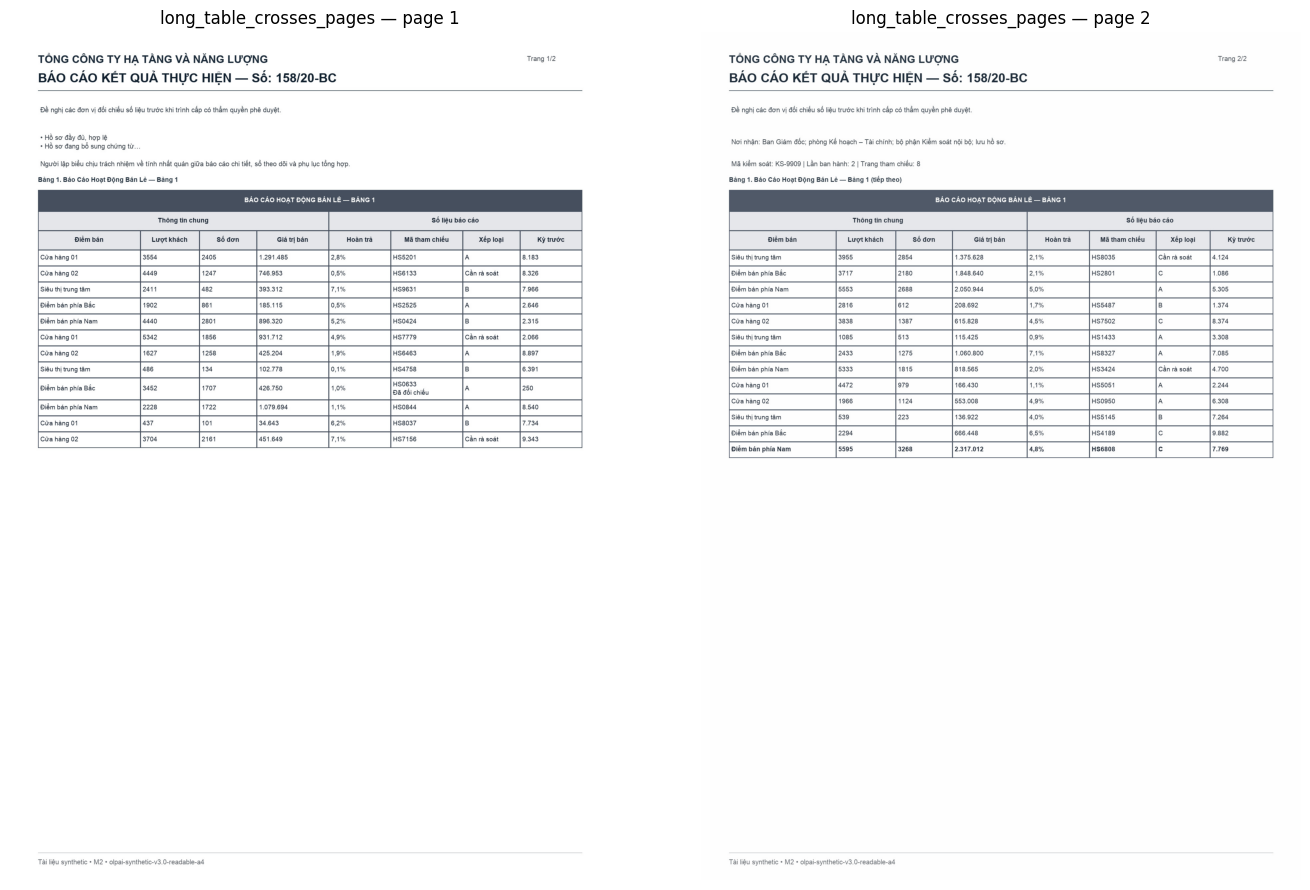


--- Page 1: page_labels/train-00314_p01.md ---
| **BÁO CÁO HOẠT ĐỘNG BÁN LẺ — BẢNG 1** | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] | [[H]] |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **Thông tin chung** | [[H]] | [[H]] | [[H]] | **Số liệu báo cáo** | [[H]] | [[H]] | [[H]] |
| **Điểm bán** | **Lượt khách** | **Số đơn** | **Giá trị bán** | **Hoàn trả** | **Mã tham chiếu** | **Xếp loại** | **Kỳ trước** |
| Cửa hàng 01 | 3554 | 2405 | 1.291.485 | 2,8% | HS5201 | A | 8.183 |
| Cửa hàng 02 | 4449 | 1247 | 746.953 | 0,5% | HS6133 | Cần rà soát | 8.326 |
| Siêu thị trung tâm | 2411 | 482 | 393.312 | 7,1% | HS9631 | B | 7.966 |
| Điểm bán phía Bắc | 1902 | 861 | 185.115 | 0,5% | HS2525 | A | 2.646 |
| Điểm bán phía Nam | 4440 | 2801 | 896.320 | 5,2% | HS0424 | B | 2.315 |
| Cửa hàng 01 | 5342 | 1856 | 931.712 | 4,9% | HS7779 | Cần rà soát | 2.066 |
... (2 dòng được ẩn) ...
| Điểm bán phía Bắc | 3452 | 1707 | 426.750 | 1,0% | HS0633<br>Đã đối chiếu | A | 250 |
| Điểm bán phía Nam 

In [7]:
assert all(record['attributes']['spans_two_pages'] == (record['page_count'] == 2)
           for record in train_records)

sample_cases = {
    'has_escaped_pipe': next(record for record in train_records
                             if record['attributes']['has_escaped_pipe']
                             and not record['attributes']['spans_two_pages']),
    'spans_two_pages_only': next(record for record in train_records
                                 if record['attributes']['spans_two_pages']
                                 and not record['attributes']['long_table_crosses_pages']),
    'long_table_crosses_pages': next(record for record in train_records
                                     if record['attributes']['long_table_crosses_pages']),
}

def preview_label(text, head=10, tail=4):
    lines = text.splitlines()
    if len(lines) <= head + tail:
        return text
    return '\n'.join([*lines[:head], f'... ({len(lines) - head - tail} dòng được ẩn) ...', *lines[-tail:]])

for case_name, record in sample_cases.items():
    attributes = record['attributes']
    print('\n' + '=' * 90)
    print(f"{case_name}: {record['id']} | difficulty={record['difficulty']} | "
          f"pages={record['page_count']} | tables={attributes['table_count']}")
    print({name: attributes[name] for name in
           ('has_escaped_pipe', 'spans_two_pages', 'long_table_crosses_pages')})

    fig, axes = plt.subplots(1, len(record['image_paths']),
                             figsize=(7 * len(record['image_paths']), 9), squeeze=False)
    for page_number, (axis, image_path) in enumerate(
            zip(axes.ravel(), record['image_paths']), start=1):
        image = cv2.imread(str(TRAIN_DIR / image_path))
        if image is None:
            raise FileNotFoundError(TRAIN_DIR / image_path)
        axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axis.set_title(f'{case_name} — page {page_number}')
        axis.axis('off')
    plt.tight_layout(); plt.show()

    if case_name == 'has_escaped_pipe':
        label = (TRAIN_DIR / record['label_path']).read_text(encoding='utf-8')
        print('Các dòng chứa escaped pipe:')
        print('\n'.join(line for line in label.splitlines() if r'\|' in line))
    else:
        for page_number, label_path in enumerate(record['page_label_paths'], start=1):
            label = (TRAIN_DIR / label_path).read_text(encoding='utf-8')
            print(f'\n--- Page {page_number}: {label_path} ---')
            print(preview_label(label))

### 2.2.3 M1–M2 overlap

Kiểm tra trực tiếp vùng giao nhau thay vì giả định difficulty có thể suy ra từ một thuộc tính duy nhất.

difficulty,M1,M2
max_columns,,
5,290,0
6,21,0
7,14,75
8,0,112
9,0,143


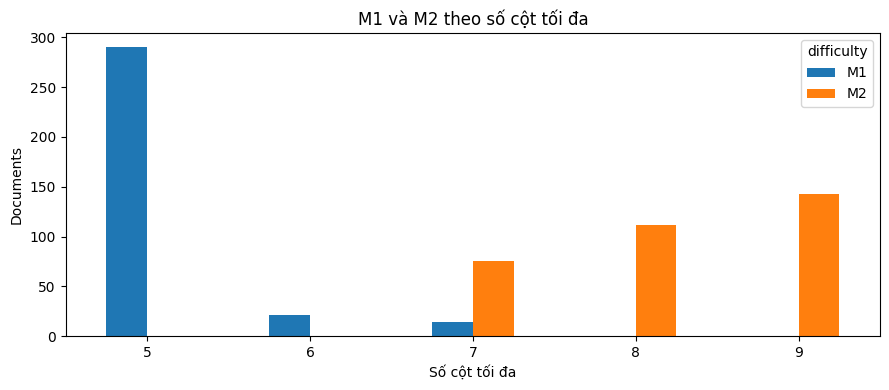

Số cột xuất hiện ở cả M1 và M2: [7]


In [8]:
m1_m2_docs = pd.DataFrame([
    {
        'doc_id': record['id'],
        'difficulty': record['difficulty'],
        'max_columns': record['attributes']['max_columns'],
        'max_data_rows': record['attributes']['max_data_rows'],
        'table_count': record['attributes']['table_count'],
        'page_count': record['page_count'],
    }
    for record in train_records if record['difficulty'] in {'M1', 'M2'}
])
column_overlap = pd.crosstab(m1_m2_docs.max_columns, m1_m2_docs.difficulty)
display(column_overlap)
column_overlap.plot(kind='bar', figsize=(9, 4), title='M1 và M2 theo số cột tối đa')
plt.xlabel('Số cột tối đa'); plt.ylabel('Documents'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

shared_column_counts = column_overlap.index[(column_overlap > 0).all(axis=1)].tolist()
print('Số cột xuất hiện ở cả M1 và M2:', shared_column_counts)

## 2.3 Structural and Visual Attributes

### 2.3.1 Extract table- and cell-level observations

Các thống kê dưới đây được đọc trực tiếp từ label, không suy ra từ metadata của test.

In [9]:
table_rows, cell_rows = [], []

for record in train_records:
    tables = parse_markdown_tables((TRAIN_DIR / record['label_path']).read_text(encoding='utf-8'))
    for table_id, table in enumerate(tables):
        row_count, col_count = len(table), len(table[0])
        h_merges = sum(cell == '[[H]]' for row in table for cell in row)
        v_merges = sum(cell == '[[V]]' for row in table for cell in row)
        table_rows.append({
            'doc_id': record['id'], 'difficulty': record['difficulty'], 'table_id': table_id,
            'rows': row_count, 'cols': col_count, 'h_markers': h_merges, 'v_markers': v_merges,
            'has_h_merge': h_merges > 0, 'has_v_merge': v_merges > 0,
        })
        for row_id, row in enumerate(table):
            row_role = 'first' if row_id == 0 else ('last' if row_id == row_count - 1 else 'middle')
            for col_id, value in enumerate(row):
                marker = value if value in MERGE_MARKERS else None
                plain = BOLD.fullmatch(value).group(1) if BOLD.fullmatch(value) else value
                cell_rows.append({
                    'doc_id': record['id'], 'difficulty': record['difficulty'], 'table_id': table_id,
                    'row': row_id, 'col': col_id, 'row_role': row_role,
                    'marker': marker, 'is_content': marker is None,
                    'is_bold': BOLD.fullmatch(value) is not None,
                    'is_multiline': '<br>' in value, 'has_escaped_pipe': r'\|' in value,
                    'text_length': len(plain.replace('<br>', '')) if marker is None else 0,
                })

table_df = pd.DataFrame(table_rows)
cell_df = pd.DataFrame(cell_rows)
print(f'Tables={len(table_df):,} | atomic positions={len(cell_df):,} | content cells={cell_df.is_content.sum():,}')

Tables=1,616 | atomic positions=253,439 | content cells=228,278


### 2.3.2 Document and page structure

In [10]:
layout_rows = []
for record in train_records:
    attributes = record['attributes']
    layout_rows.append({
        'difficulty': record['difficulty'],
        'layout': f"{attributes['table_count']}T{record['page_count']}P",
        'border_mode': attributes['border_mode'],
    })
layout_df = pd.DataFrame(layout_rows)
display(pd.crosstab(layout_df.layout, layout_df.difficulty))
display(pd.crosstab(layout_df.border_mode, layout_df.difficulty))

difficulty,M1,M2,M3,M4
layout,,,,
1T1P,325,166,0,0
1T2P,0,36,85,63
2T1P,0,128,142,64
3T2P,0,0,53,38


difficulty,M1,M2,M3,M4
border_mode,,,,
grid,325,330,115,0
horizontal,0,0,70,59
none,0,0,38,40
zebra,0,0,57,66


#### Ảnh mẫu theo layout và border mode

Mỗi category lấy document đầu tiên trong manifest và hiển thị toàn bộ trang.

layout=1T1P | train-00000 | difficulty=M1 | pages=1 | tables=1


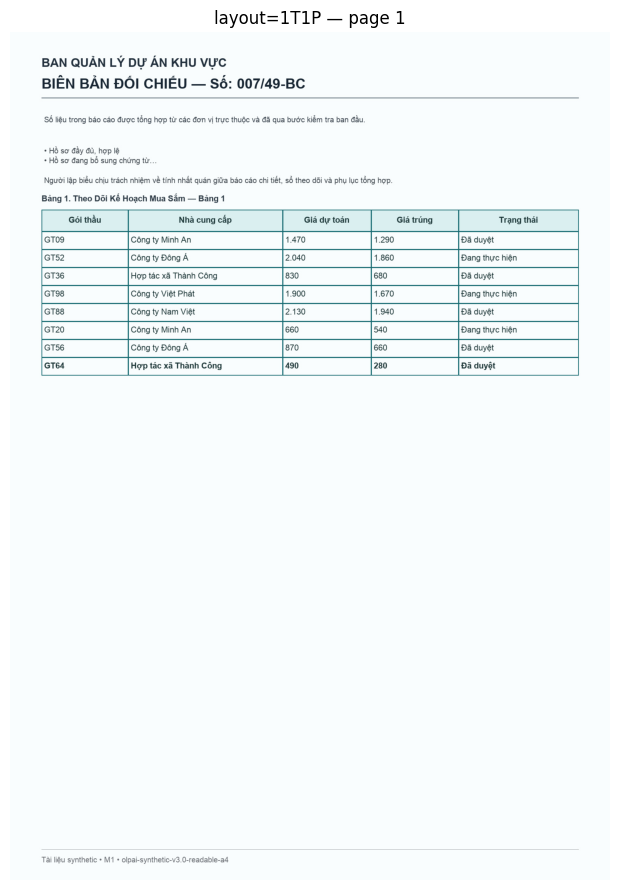

layout=1T2P | train-00314 | difficulty=M2 | pages=2 | tables=1


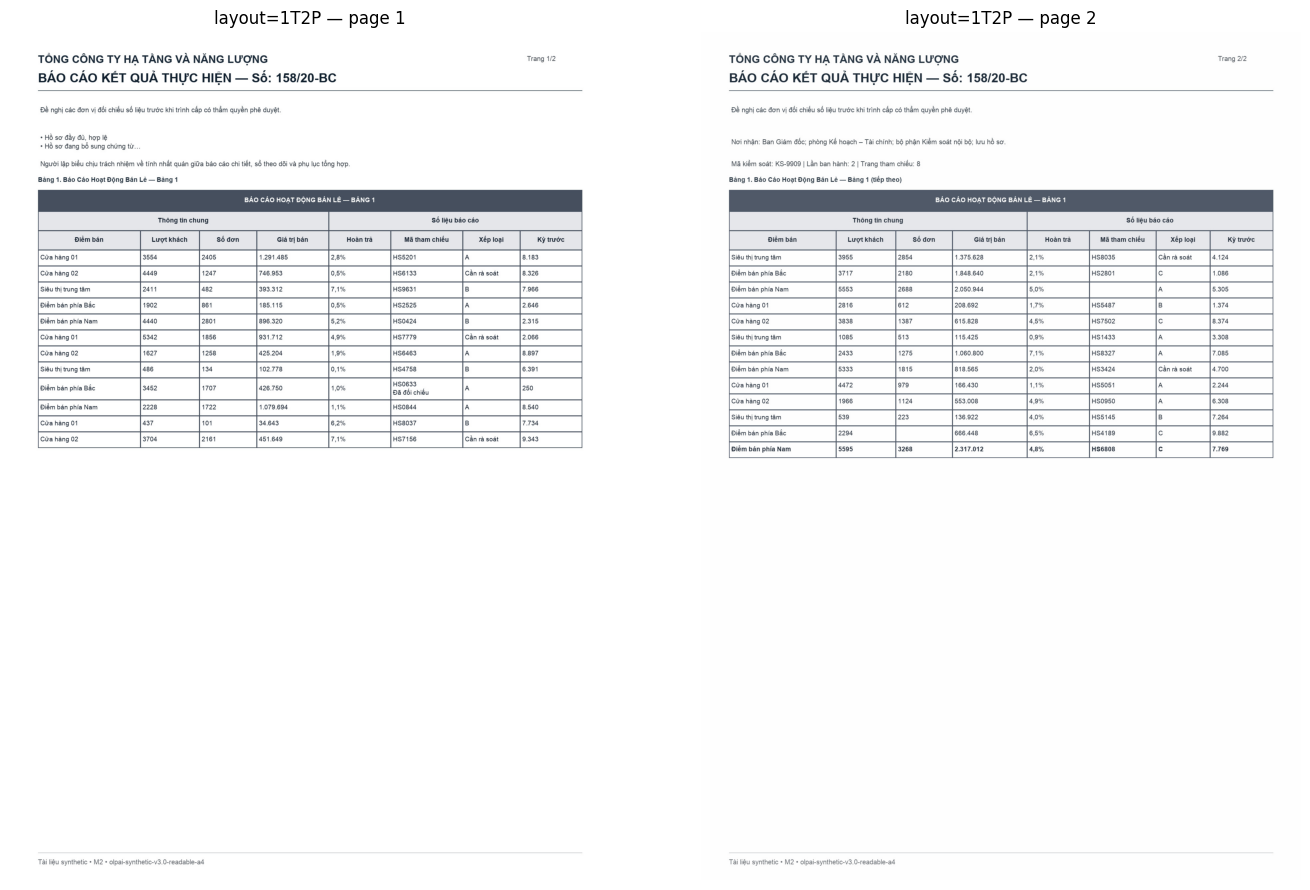

layout=2T1P | train-00302 | difficulty=M2 | pages=1 | tables=2


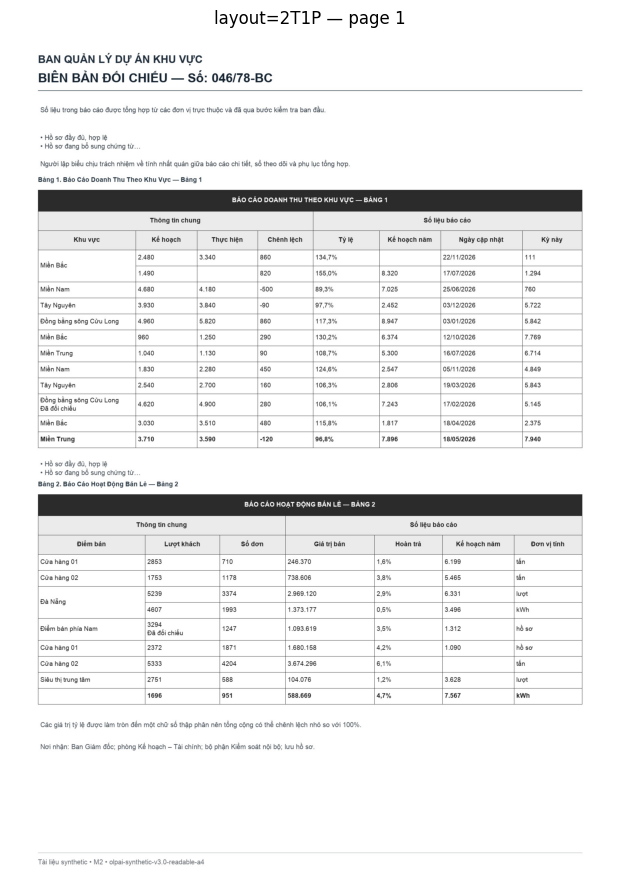

layout=3T2P | train-00601 | difficulty=M3 | pages=2 | tables=3


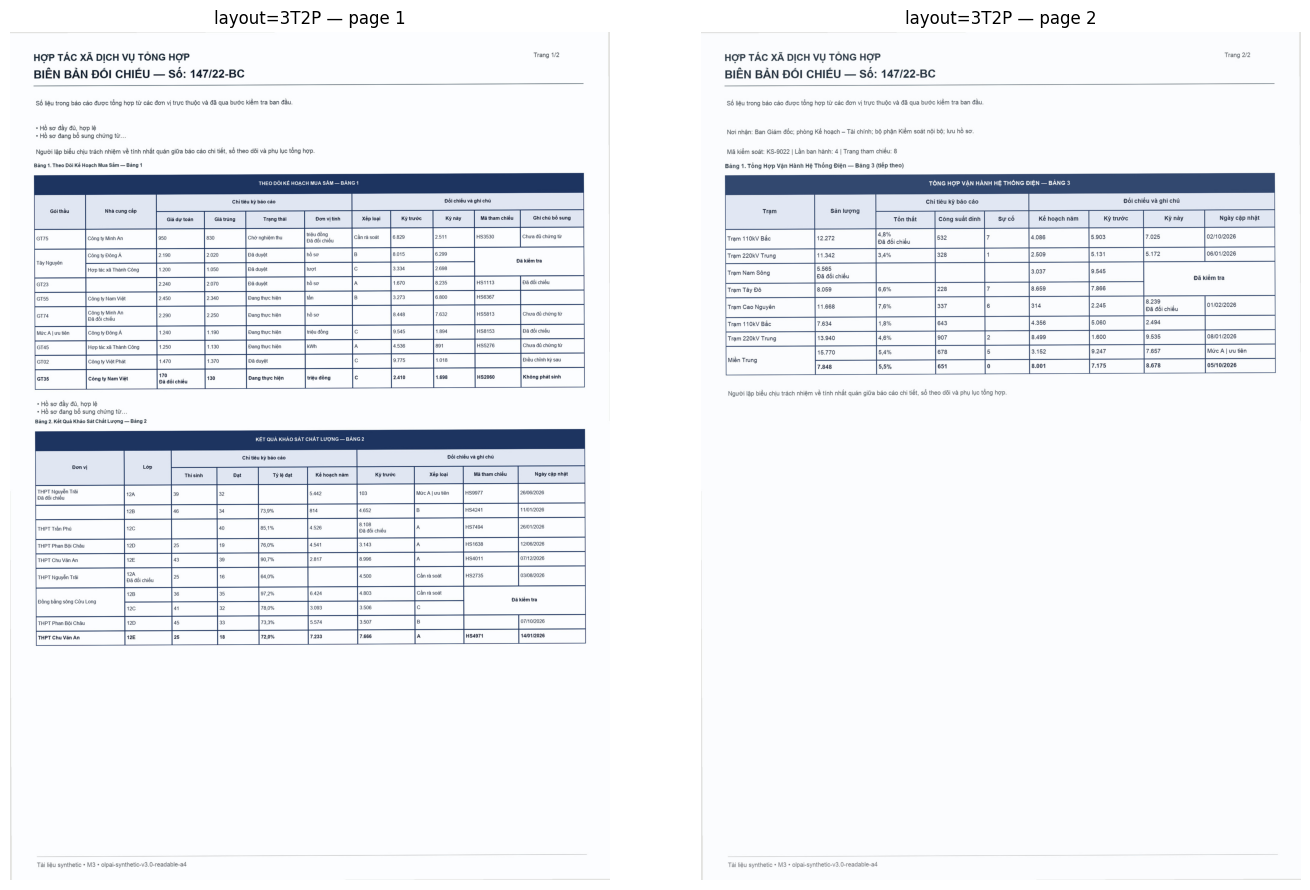

border_mode=grid | train-00000 | difficulty=M1 | pages=1 | tables=1


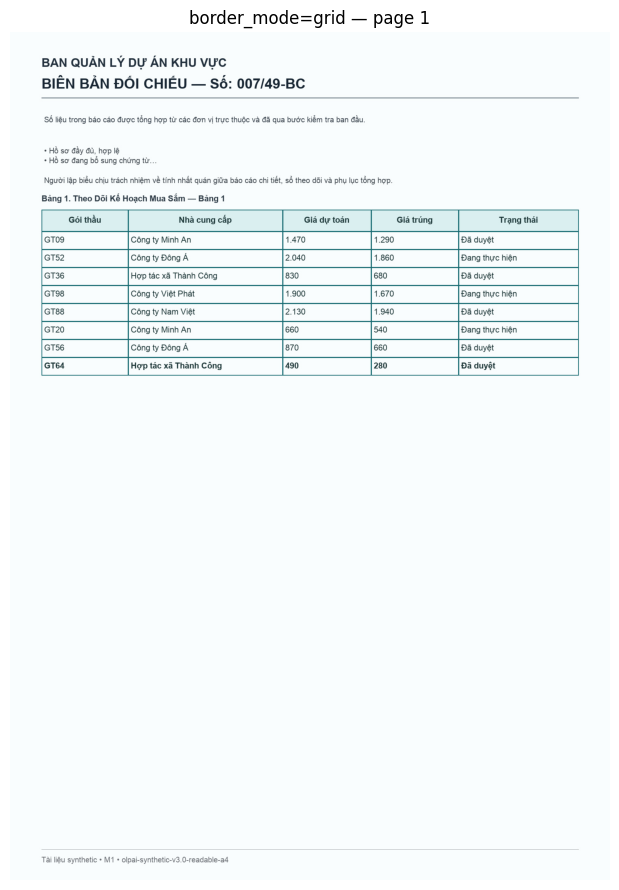

border_mode=horizontal | train-00602 | difficulty=M3 | pages=2 | tables=1


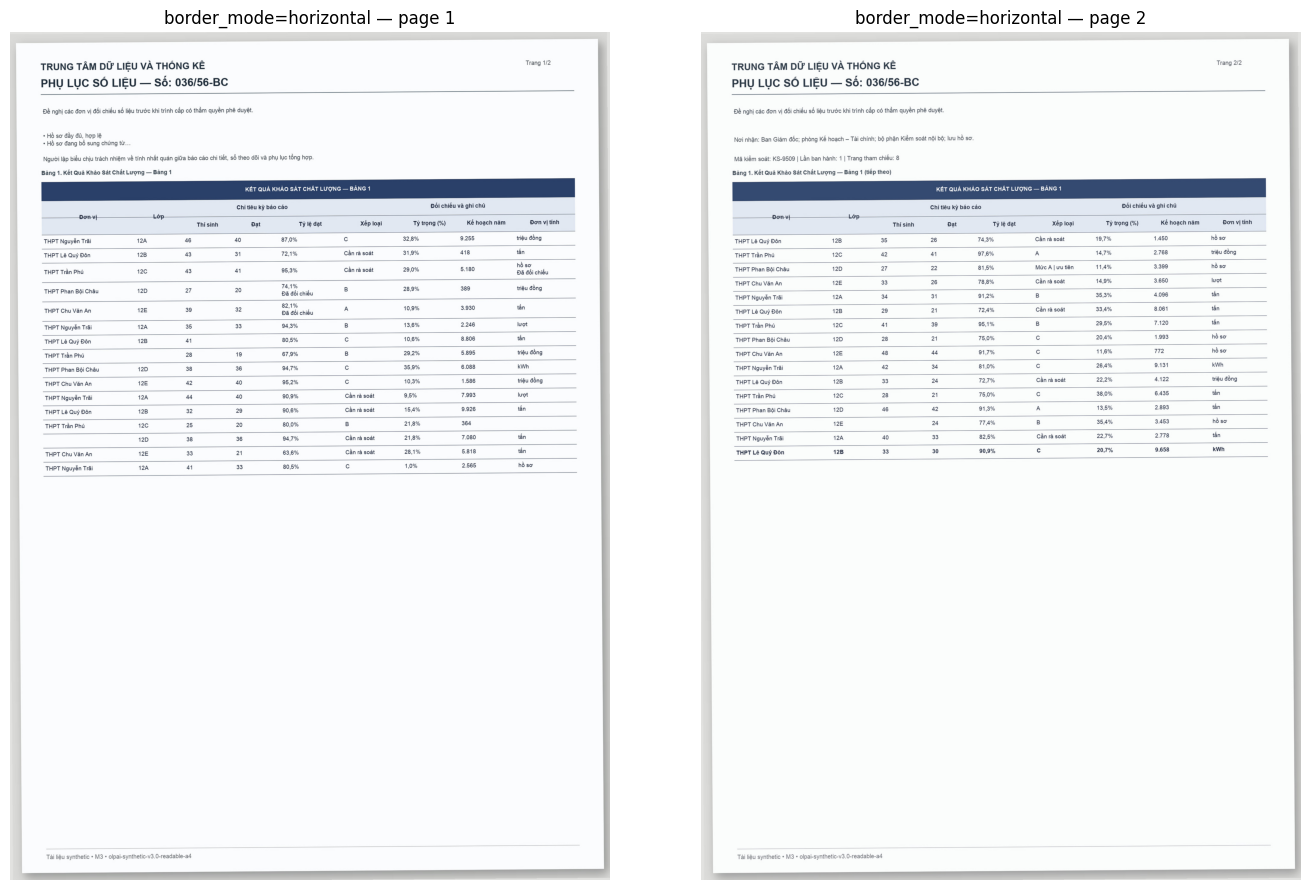

border_mode=none | train-00600 | difficulty=M3 | pages=2 | tables=1


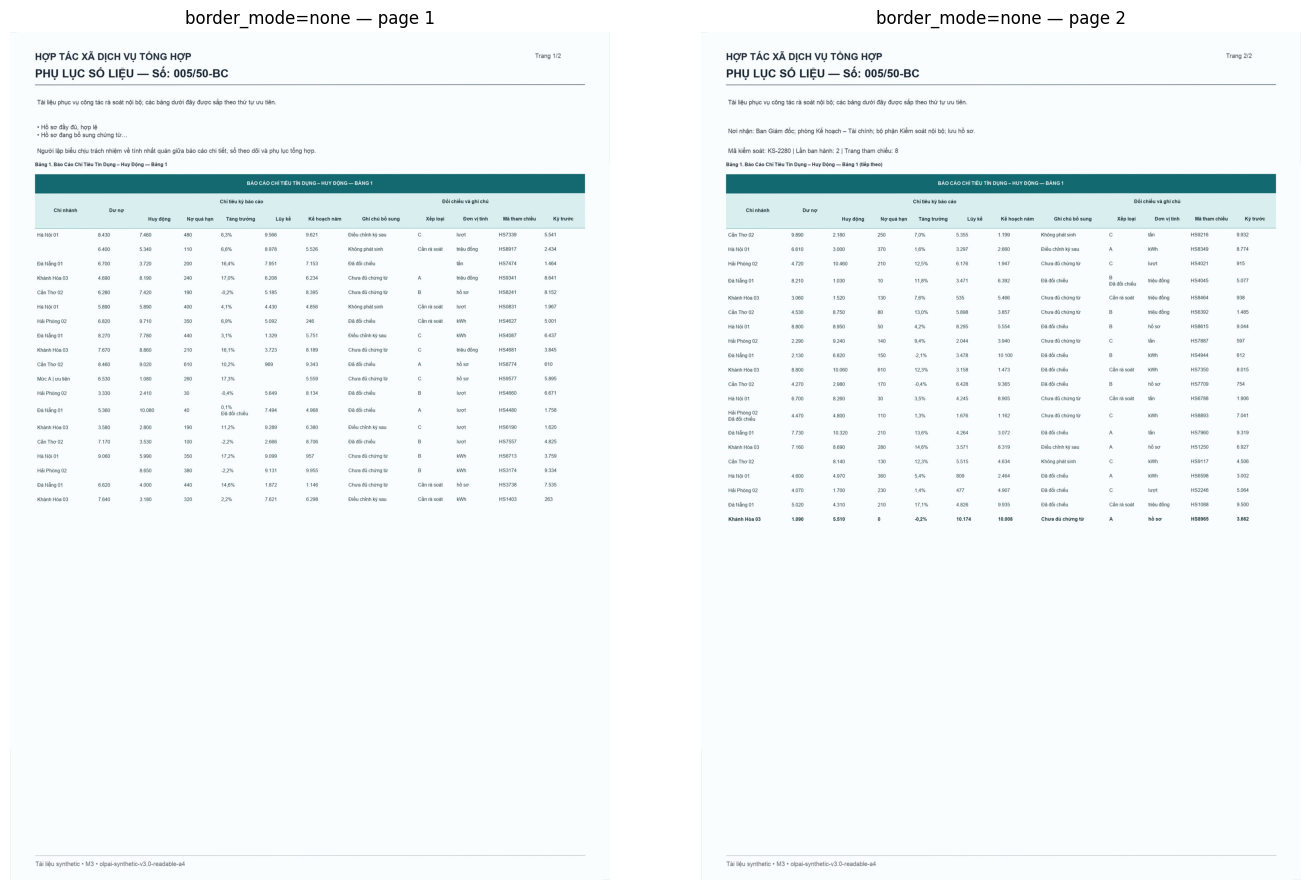

border_mode=zebra | train-00604 | difficulty=M3 | pages=2 | tables=1


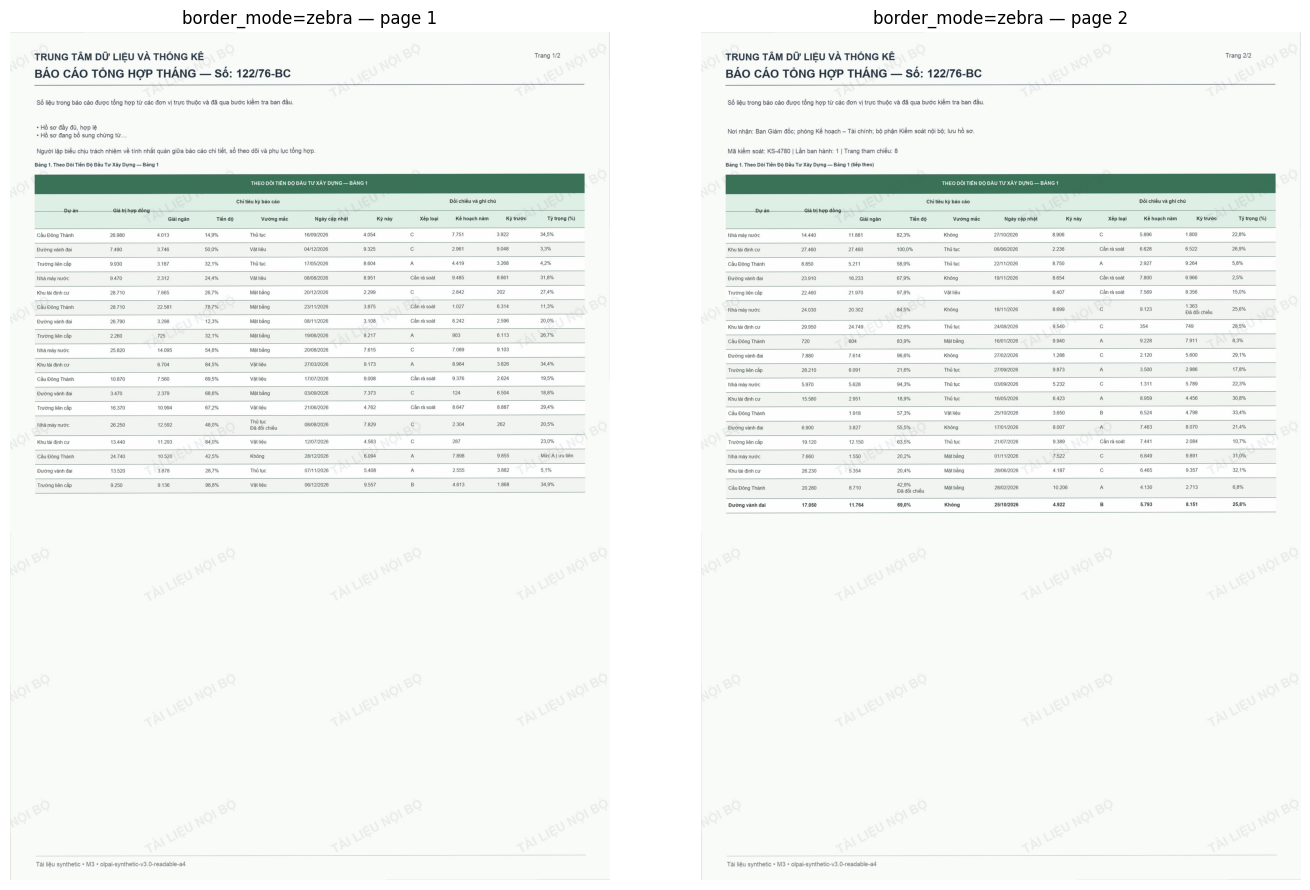

In [11]:
layout_samples = {
    layout: next(record for record in train_records
                 if f"{record['attributes']['table_count']}T{record['page_count']}P" == layout)
    for layout in sorted(layout_df.layout.unique())
}
border_samples = {
    border: next(record for record in train_records
                 if record['attributes']['border_mode'] == border)
    for border in sorted(layout_df.border_mode.unique())
}

for category, samples in [('layout', layout_samples), ('border_mode', border_samples)]:
    for value, record in samples.items():
        print(f"{category}={value} | {record['id']} | difficulty={record['difficulty']} | "
              f"pages={record['page_count']} | tables={record['attributes']['table_count']}")
        fig, axes = plt.subplots(1, record['page_count'],
                                 figsize=(7 * record['page_count'], 9), squeeze=False)
        for page_number, (axis, image_path) in enumerate(
                zip(axes.ravel(), record['image_paths']), start=1):
            image = cv2.imread(str(TRAIN_DIR / image_path))
            if image is None:
                raise FileNotFoundError(TRAIN_DIR / image_path)
            axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            axis.set_title(f'{category}={value} — page {page_number}')
            axis.axis('off')
        plt.tight_layout(); plt.show()

### 2.3.3 Table dimensions

rows                                               cols         \
            count   mean    std   min   25%   50%   75%   max  count   mean   
difficulty                                                                    
M1          325.0   7.42   1.15   6.0   6.0   7.0   8.0   9.0  325.0   5.15   
M2          458.0  16.05   4.81  11.0  13.0  15.0  18.0  33.0  458.0   8.02   
M3          528.0  18.41   9.34  12.0  13.0  15.0  17.0  45.0  528.0  10.48   
M4          305.0  21.62  11.36  13.0  15.0  17.0  19.0  51.0  305.0  12.23   

                                                
             std   min   25%   50%   75%   max  
difficulty                                      
M1          0.46   5.0   5.0   5.0   5.0   7.0  
M2          0.81   7.0   7.0   8.0   9.0   9.0  
M3          1.09   9.0  10.0  10.0  11.0  12.0  
M4          1.37  10.0  11.0  12.0  13.0  14.0

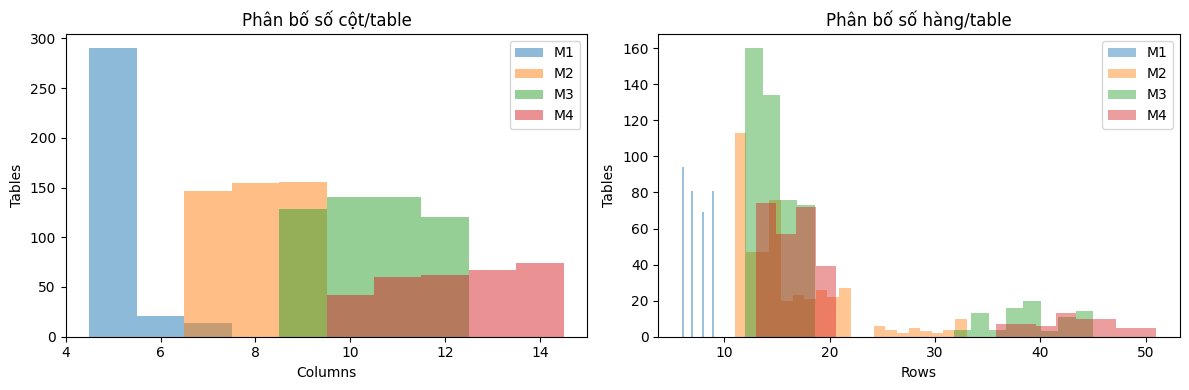

In [12]:
display(table_df.groupby('difficulty')[['rows', 'cols']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for difficulty, frame in table_df.groupby('difficulty'):
    axes[0].hist(frame.cols, bins=np.arange(table_df.cols.min(), table_df.cols.max() + 2) - 0.5,
                 alpha=0.5, label=difficulty)
    axes[1].hist(frame.rows, bins=20, alpha=0.45, label=difficulty)
axes[0].set(title='Phân bố số cột/table', xlabel='Columns', ylabel='Tables')
axes[1].set(title='Phân bố số hàng/table', xlabel='Rows', ylabel='Tables')
for axis in axes: axis.legend()
plt.tight_layout(); plt.show()

### 2.3.4 Merge topology

So sánh hướng merge, vị trí theo hàng và mức độ tập trung theo difficulty.

,tables,tables_with_h_merge,tables_with_v_merge,h_markers,v_markers
difficulty,,,,,
M1,325,0,0,0,0
M2,458,458,422,5972,422
M3,528,528,528,9310,1942
M4,305,305,305,6421,1094


marker               [[H]]  [[V]]
difficulty row_role              
M2         first      3215      0
           last          0     38
           middle     2757    384
M3         first      5004      0
           last         44     93
           middle     4262   1849
M4         first      3426      0
           last         23     48
           middle     2972   1046

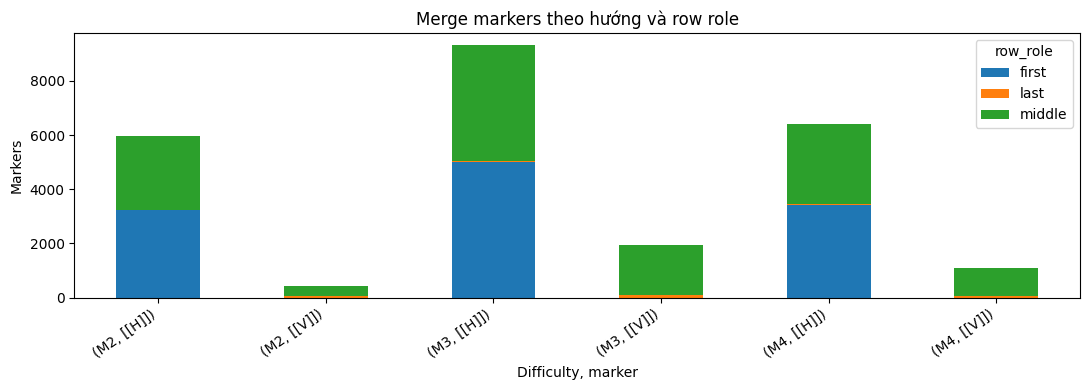

In [13]:
merge_summary = (table_df.groupby('difficulty')
                 .agg(tables=('doc_id', 'size'), tables_with_h_merge=('has_h_merge', 'sum'),
                      tables_with_v_merge=('has_v_merge', 'sum'),
                      h_markers=('h_markers', 'sum'), v_markers=('v_markers', 'sum')))
display(merge_summary)

merge_positions = cell_df.loc[cell_df.marker.notna(), ['difficulty', 'marker', 'row_role']]
display(pd.crosstab([merge_positions.difficulty, merge_positions.row_role], merge_positions.marker))

merge_positions.groupby(['difficulty', 'marker', 'row_role']).size().unstack(fill_value=0).plot(
    kind='bar', stacked=True, figsize=(11, 4), title='Merge markers theo hướng và row role')
plt.xlabel('Difficulty, marker'); plt.ylabel('Markers'); plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()

#### Tỷ lệ bảng có merge ở M1 và M2

Biểu đồ này đếm **bảng có ít nhất một merge**, không đếm số `[[H]]`/`[[V]]` markers. Dùng trực tiếp cho phần evidence của slide Merge Structure.

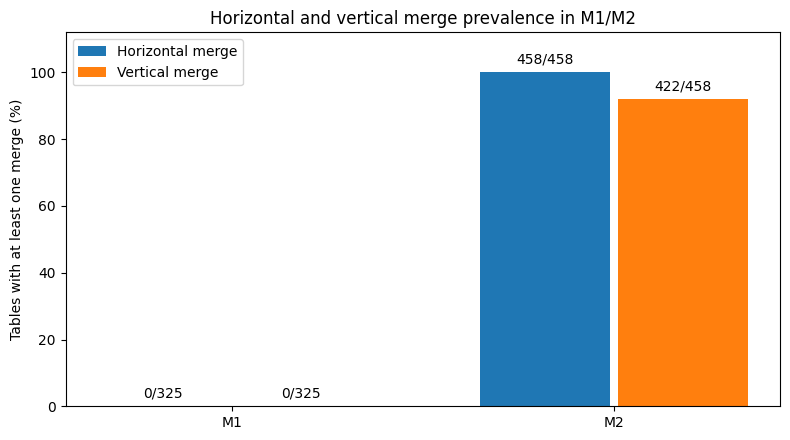

In [14]:
merge_target = merge_summary.loc[['M1', 'M2']]
merge_types = [('tables_with_h_merge', 'Horizontal merge'),
               ('tables_with_v_merge', 'Vertical merge')]
x = np.arange(len(merge_target))
fig, ax = plt.subplots(figsize=(8, 4.5))
for offset, (column, label) in zip((-0.18, 0.18), merge_types):
    counts = merge_target[column].to_numpy()
    totals = merge_target['tables'].to_numpy()
    bars = ax.bar(x + offset, counts / totals * 100, width=0.34, label=label)
    for bar, count, total in zip(bars, counts, totals):
        ax.annotate(f'{count}/{total}', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points', ha='center', va='bottom')
ax.set_xticks(x, merge_target.index)
ax.set_ylim(0, 112)
ax.set_ylabel('Tables with at least one merge (%)')
ax.set_title('Horizontal and vertical merge prevalence in M1/M2')
ax.legend()
plt.tight_layout(); plt.show()

### 2.3.5 Content and formatting

In [15]:
content_df = cell_df.loc[cell_df.is_content].copy()
format_summary = (content_df.groupby('difficulty')
                  .agg(cells=('is_content', 'size'), bold_rate=('is_bold', 'mean'),
                       multiline_rate=('is_multiline', 'mean'), pipe_rate=('has_escaped_pipe', 'mean'),
                       median_text_length=('text_length', 'median'),
                       p95_text_length=('text_length', lambda values: values.quantile(.95))))
display(format_summary.style.format({
    'bold_rate': '{:.1%}', 'multiline_rate': '{:.1%}', 'pipe_rate': '{:.1%}',
    'median_text_length': '{:.1f}', 'p95_text_length': '{:.1f}',
}))

bold_by_role = content_df.groupby(['difficulty', 'row_role']).is_bold.agg(['size', 'mean'])
display(bold_by_role.rename(columns={'size': 'cells', 'mean': 'bold_rate'}).style.format({'bold_rate': '{:.1%}'}))

,cells,bold_rate,multiline_rate,pipe_rate,median_text_length,p95_text_length
difficulty,,,,,,
M1,12424,26.9%,0.0%,0.0%,5.0,15.0
M2,52573,16.4%,0.9%,0.0%,5.0,16.0
M3,90538,14.1%,1.7%,0.6%,5.0,17.0
M4,72743,11.5%,2.5%,0.4%,5.0,16.0


### 2.3.6 M2 header grammar at page-table level

Solution nhìn thấy từng page trước khi stitch, nên audit này đọc `page_labels` thay vì document label. Mỗi hàng được mã hóa thành `A` (content anchor), `H` (`[[H]]`) hoặc `V` (`[[V]]`) rồi so với grammar đang được giả định.

In [16]:
def marker_signature(row):
    return ''.join('H' if cell == '[[H]]' else 'V' if cell == '[[V]]' else 'A' for cell in row)

m2_page_tables = []
for record in (record for record in train_records if record['difficulty'] == 'M2'):
    group = f"{record['attributes']['table_count']}T{record['page_count']}P"
    for page_index, label_path in enumerate(record['page_label_paths']):
        for table_id, table in enumerate(parse_markdown_tables(
                (TRAIN_DIR / label_path).read_text(encoding='utf-8'))):
            m2_page_tables.append({
                'doc_id': record['id'], 'group': group, 'page_index': page_index,
                'table_id': table_id, 'table': table,
            })

header_rows = []
for item in m2_page_tables:
    table, cols = item['table'], len(item['table'][0])
    split = cols // 2
    signatures = [marker_signature(row) for row in table[:3]]
    row0_expected = 'A' + 'H' * (cols - 1)
    row1_expected = 'A' + 'H' * (split - 1) + 'A' + 'H' * (cols - split - 1)
    row0_full_span = len(signatures) >= 1 and signatures[0] == row0_expected
    row1_two_groups_at_half = len(signatures) >= 2 and signatures[1] == row1_expected
    row2_leaf_headers = len(signatures) >= 3 and signatures[2] == 'A' * cols
    header_rows.append({
        **{key: item[key] for key in ('doc_id', 'group', 'page_index', 'table_id')},
        'cols': cols, 'row0_signature': signatures[0] if signatures else '',
        'row1_signature': signatures[1] if len(signatures) > 1 else '',
        'row2_signature': signatures[2] if len(signatures) > 2 else '',
        'row0_full_span': row0_full_span,
        'row1_two_groups_at_half': row1_two_groups_at_half,
        'row2_leaf_headers': row2_leaf_headers,
        'exact_header_grammar': row0_full_span and row1_two_groups_at_half and row2_leaf_headers,
    })

header_grammar_df = pd.DataFrame(header_rows)
grammar_metrics = ['row0_full_span', 'row1_two_groups_at_half',
                   'row2_leaf_headers', 'exact_header_grammar']
display(pd.DataFrame({
    'matching_tables': header_grammar_df[grammar_metrics].sum(),
    'total_tables': len(header_grammar_df),
    'match_rate': header_grammar_df[grammar_metrics].mean(),
}).style.format({'match_rate': '{:.1%}'}))
display(header_grammar_df.groupby(['group', 'cols'])[grammar_metrics]
        .agg(['size', 'mean']).style.format('{:.1%}', subset=pd.IndexSlice[:, pd.IndexSlice[:, 'mean']]))
display(header_grammar_df.loc[~header_grammar_df.exact_header_grammar].head(20))

,matching_tables,total_tables,match_rate
row0_full_span,494,494,100.0%
row1_two_groups_at_half,494,494,100.0%
row2_leaf_headers,494,494,100.0%
exact_header_grammar,494,494,100.0%


,doc_id,group,page_index,table_id,cols,row0_signature,row1_signature,row2_signature,row0_full_span,row1_two_groups_at_half,row2_leaf_headers,exact_header_grammar


### 2.3.7 Bold grammar by exact row role

Đếm cả cell-level bold rate và tỷ lệ cả hàng đều bold. `last` được tách theo context để không trộn last row của page 1 đang tiếp tục với terminal row thực sự.

In [17]:
bold_exact_cells, bold_exact_rows = [], []
for item in m2_page_tables:
    table = item['table']
    for row_index, row in enumerate(table):
        if row_index < 3:
            role = f'row_{row_index}'
        elif row_index == len(table) - 1:
            role = 'last'
        else:
            role = 'body'
        values = [cell for cell in row if cell not in MERGE_MARKERS and cell.strip()]
        flags = [BOLD.fullmatch(cell) is not None for cell in values]
        if role == 'last':
            if item['group'].endswith('1P'):
                context = 'one_page_terminal'
            elif item['page_index'] == 0:
                context = 'two_page_page1_continuation'
            else:
                context = 'two_page_page2_terminal'
        else:
            context = role
        bold_exact_rows.append({
            **{key: item[key] for key in ('doc_id', 'group', 'page_index', 'table_id')},
            'row_index': row_index, 'row_role': role, 'context': context,
            'content_cells': len(flags), 'all_bold': bool(flags) and all(flags),
            'any_bold': any(flags),
        })
        bold_exact_cells.extend({
            'doc_id': item['doc_id'], 'row_role': role, 'context': context, 'is_bold': flag
        } for flag in flags)

bold_exact_cell_df = pd.DataFrame(bold_exact_cells)
bold_exact_row_df = pd.DataFrame(bold_exact_rows)
cell_bold_summary = bold_exact_cell_df.groupby('row_role').is_bold.agg(cells='size', bold_rate='mean')
row_bold_summary = bold_exact_row_df.groupby('row_role').agg(
    rows=('all_bold', 'size'), all_bold_rate=('all_bold', 'mean'), any_bold_rate=('any_bold', 'mean'))
display(cell_bold_summary.style.format({'bold_rate': '{:.1%}'}))
display(row_bold_summary.style.format({'all_bold_rate': '{:.1%}', 'any_bold_rate': '{:.1%}'}))
display(bold_exact_row_df.loc[bold_exact_row_df.row_role.eq('last')]
        .groupby('context').agg(rows=('all_bold', 'size'), all_bold_rate=('all_bold', 'mean'),
                                any_bold_rate=('any_bold', 'mean'))
        .style.format({'all_bold_rate': '{:.1%}', 'any_bold_rate': '{:.1%}'}))
display(bold_exact_row_df.loc[bold_exact_row_df.row_role.isin(['row_0', 'row_1', 'row_2'])
                              & ~bold_exact_row_df.all_bold].head(20))

,cells,bold_rate
row_role,,
body,42767,0.0%
last,3843,92.5%
row_0,494,100.0%
row_1,988,100.0%
row_2,3960,100.0%


,rows,all_bold_rate,any_bold_rate
row_role,,,
body,5481,0.0%,0.0%
last,494,92.7%,92.7%
row_0,494,100.0%,100.0%
row_1,494,100.0%,100.0%
row_2,494,100.0%,100.0%


,rows,all_bold_rate,any_bold_rate
context,,,
one_page_terminal,422,100.0%,100.0%
two_page_page1_continuation,36,0.0%,0.0%
two_page_page2_terminal,36,100.0%,100.0%


,doc_id,group,page_index,table_id,row_index,row_role,context,content_cells,all_bold,any_bold


**Gate cho stroke EDA:** chỉ đo stroke score nếu bảng context của `last` có cả positive và negative rows mà grammar không phân biệt được. Nếu terminal rows đã deterministic theo context, thêm threshold ảnh chỉ làm solution phức tạp hơn mà không có thêm evidence.

### 2.3.8 Cross-page header repetition and reconstruction

Audit toàn bộ M2 two-page documents: số bảng mỗi page, số cột, số hàng prefix lặp lại và khả năng khôi phục document label bằng cách bỏ ba hàng đầu của page 2.

In [18]:
def common_prefix_length(left, right):
    count = 0
    for left_row, right_row in zip(left, right):
        if left_row != right_row:
            break
        count += 1
    return count

cross_page_rows = []
for record in (record for record in train_records
               if record['difficulty'] == 'M2' and record['page_count'] == 2):
    page_tables = [parse_markdown_tables((TRAIN_DIR / path).read_text(encoding='utf-8'))
                   for path in record['page_label_paths']]
    document_tables = parse_markdown_tables(
        (TRAIN_DIR / record['label_path']).read_text(encoding='utf-8'))
    one_table_each_page = all(len(tables) == 1 for tables in page_tables)
    one_document_table = len(document_tables) == 1
    if one_table_each_page:
        first, second = page_tables[0][0], page_tables[1][0]
        same_columns = len(first[0]) == len(second[0])
        exact_prefix = common_prefix_length(first, second)
        first_signatures = [marker_signature(row) for row in first]
        second_signatures = [marker_signature(row) for row in second]
        structural_prefix = common_prefix_length(first_signatures, second_signatures)
        first_three_exact = len(first) >= 3 and len(second) >= 3 and first[:3] == second[:3]
        first_three_structure = (len(first_signatures) >= 3 and len(second_signatures) >= 3
                                 and first_signatures[:3] == second_signatures[:3])
        reconstructed = one_document_table and [*first, *second[3:]] == document_tables[0]
    else:
        same_columns = first_three_exact = first_three_structure = reconstructed = False
        exact_prefix = structural_prefix = 0
    cross_page_rows.append({
        'doc_id': record['id'], 'one_table_each_page': one_table_each_page,
        'one_document_table': one_document_table, 'same_column_count': same_columns,
        'exact_common_prefix_rows': exact_prefix,
        'structural_common_prefix_rows': structural_prefix,
        'first_three_rows_exact': first_three_exact,
        'first_three_rows_same_structure': first_three_structure,
        'document_reconstructed_by_drop3': reconstructed,
    })

cross_page_df = pd.DataFrame(cross_page_rows)
cross_metrics = ['one_table_each_page', 'one_document_table', 'same_column_count',
                 'first_three_rows_exact', 'first_three_rows_same_structure',
                 'document_reconstructed_by_drop3']
display(pd.DataFrame({
    'matching_documents': cross_page_df[cross_metrics].sum(),
    'total_documents': len(cross_page_df),
    'match_rate': cross_page_df[cross_metrics].mean(),
}).style.format({'match_rate': '{:.1%}'}))
display(pd.crosstab(cross_page_df.exact_common_prefix_rows, columns='documents'))
display(cross_page_df.loc[~cross_page_df.document_reconstructed_by_drop3].head(20))

,matching_documents,total_documents,match_rate
one_table_each_page,36,36,100.0%
one_document_table,36,36,100.0%
same_column_count,36,36,100.0%
first_three_rows_exact,36,36,100.0%
first_three_rows_same_structure,36,36,100.0%
document_reconstructed_by_drop3,36,36,100.0%


col_0,documents
exact_common_prefix_rows,
3,36


,doc_id,one_table_each_page,one_document_table,same_column_count,exact_common_prefix_rows,structural_common_prefix_rows,first_three_rows_exact,first_three_rows_same_structure,document_reconstructed_by_drop3


Audit trên chứng minh hoặc bác bỏ `STITCH_HEADER_ROWS = 3` và tính ổn định của column count ở cấp label. Nó **chưa** chứng minh pixel-geometry tolerance như `0.025`; tolerance đó cần một experiment riêng trên detected normalized column edges của positive same-document pairs và negative same-column-count pairs.

### 2.3.9 Page appearance and content density

Các metric toàn trang dưới đây mô tả mức độ phủ nội dung: `global_intensity_std` đo biến thiên mức xám, `global_edge_energy` đo lượng cạnh, và `page_ink_density` đo tỷ lệ foreground. Chúng chịu ảnh hưởng của ô trống, số chữ và đường kẻ nên **không phải các chỉ số chất lượng ảnh độc lập**. Khi đối chiếu với `page_count` và cross-page attributes, chúng chỉ cung cấp supporting evidence về nội dung dày hoặc trải dài; bằng chứng trực tiếp vẫn đến từ metadata và page labels. `near_horizontal_angle` được giữ riêng để mô tả skew.

In [19]:
def estimate_near_horizontal_angle(gray):
    scale = min(1.0, 1000 / gray.shape[1])
    small = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA) if scale < 1 else gray
    edges = cv2.Canny(small, 60, 180)
    height, width = small.shape
    lines = cv2.HoughLinesP(edges, 1, np.pi / 720, threshold=max(50, width // 12),
                            minLineLength=max(100, width // 5), maxLineGap=max(10, width // 80))
    if lines is None:
        return np.nan
    angles = []
    for x0, y0, x1, y1 in np.asarray(lines).reshape(-1, 4):
        angle = np.degrees(np.arctan2(y1 - y0, x1 - x0))
        angle = (angle + 90) % 180 - 90
        if abs(angle) <= 5:
            angles.append(angle)
    return float(np.median(angles)) if angles else np.nan

page_rows = [
    {'doc_id': record['id'], 'difficulty': record['difficulty'], 'image_path': image_path}
    for record in train_records for image_path in record['image_paths']
]
page_frame = pd.DataFrame(page_rows)
if IMAGE_SAMPLE_PER_DIFFICULTY is not None:
    page_frame = pd.concat([
        frame.sample(min(len(frame), IMAGE_SAMPLE_PER_DIFFICULTY), random_state=RANDOM_STATE)
        for _, frame in page_frame.groupby('difficulty')
    ], ignore_index=True)

image_rows = []
for sample in page_frame.itertuples(index=False):
    gray = cv2.imread(str(TRAIN_DIR / sample.image_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        continue
    otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    image_rows.append({
        'doc_id': sample.doc_id, 'difficulty': sample.difficulty,
        'height': gray.shape[0], 'width': gray.shape[1],
        'aspect_ratio': gray.shape[1] / gray.shape[0],
        'brightness': float(gray.mean()),
        'global_intensity_std': float(gray.std()),
        'global_edge_energy': float(cv2.Laplacian(gray, cv2.CV_64F).var()),
        'page_ink_density': float(np.count_nonzero(otsu) / otsu.size),
        'near_horizontal_angle': estimate_near_horizontal_angle(gray),
    })
image_df = pd.DataFrame(image_rows)
display(image_df.groupby('difficulty').agg(
    pages=('doc_id', 'size'), median_width=('width', 'median'), median_height=('height', 'median'),
    median_intensity_std=('global_intensity_std', 'median'),
    median_edge_energy=('global_edge_energy', 'median'),
    median_page_ink_density=('page_ink_density', 'median'),
    median_abs_angle=('near_horizontal_angle', lambda values: values.abs().median()),
).round(3))

,pages,median_width,median_height,median_intensity_std,median_edge_energy,median_page_ink_density,median_abs_angle
difficulty,,,,,,,
M1,80,1600.0,2263.0,27.696,1252.115,0.024,0.000
M2,80,1800.0,2546.0,44.794,2512.420,0.066,0.000
M3,80,2000.0,2828.0,39.369,1500.052,0.063,0.251
M4,80,2000.0,2828.0,37.769,936.567,0.061,1.997


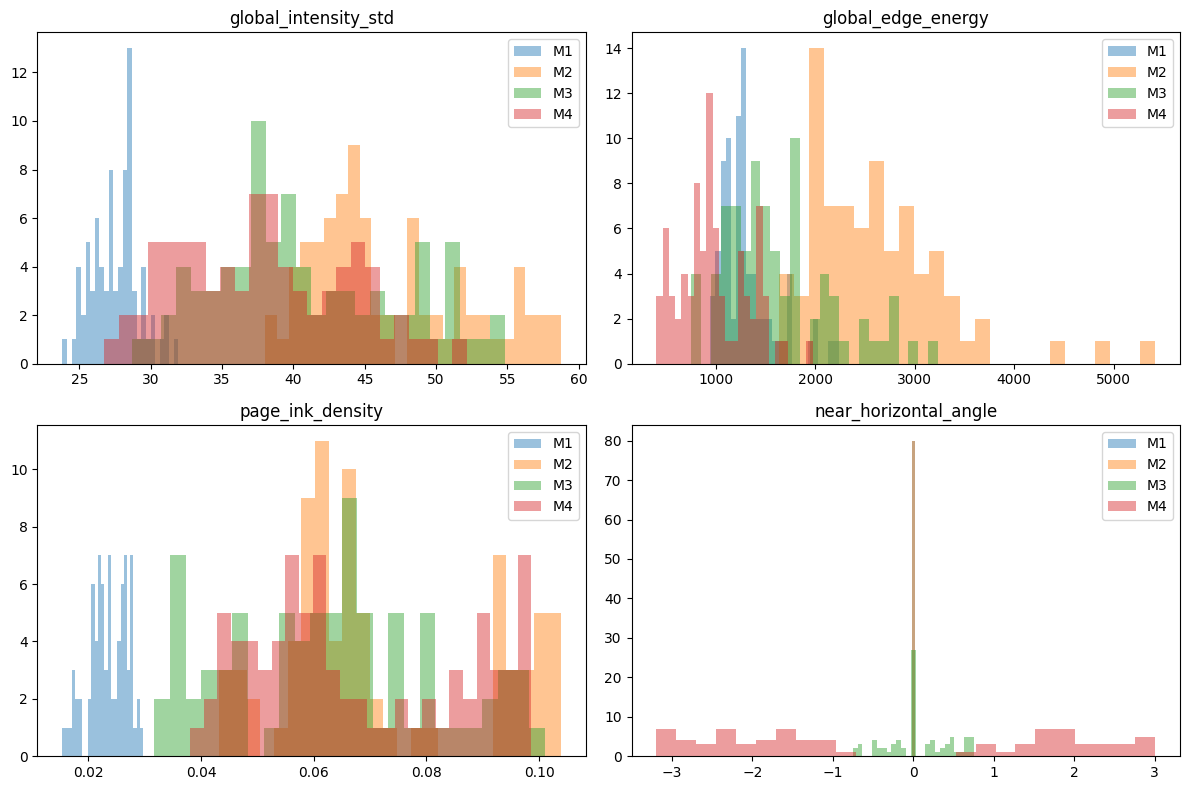

In [20]:
metrics = ['global_intensity_std', 'global_edge_energy', 'page_ink_density', 'near_horizontal_angle']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, metric in zip(axes.ravel(), metrics):
    for difficulty, frame in image_df.groupby('difficulty'):
        axis.hist(frame[metric].dropna(), bins=25, alpha=0.45, label=difficulty)
    axis.set_title(metric)
    axis.legend()
plt.tight_layout(); plt.show()

### 2.3.10 Representative examples

Xem mẫu ngẫu nhiên theo difficulty để kiểm tra xem thống kê tổng hợp có che khuất ngoại lệ hay không.

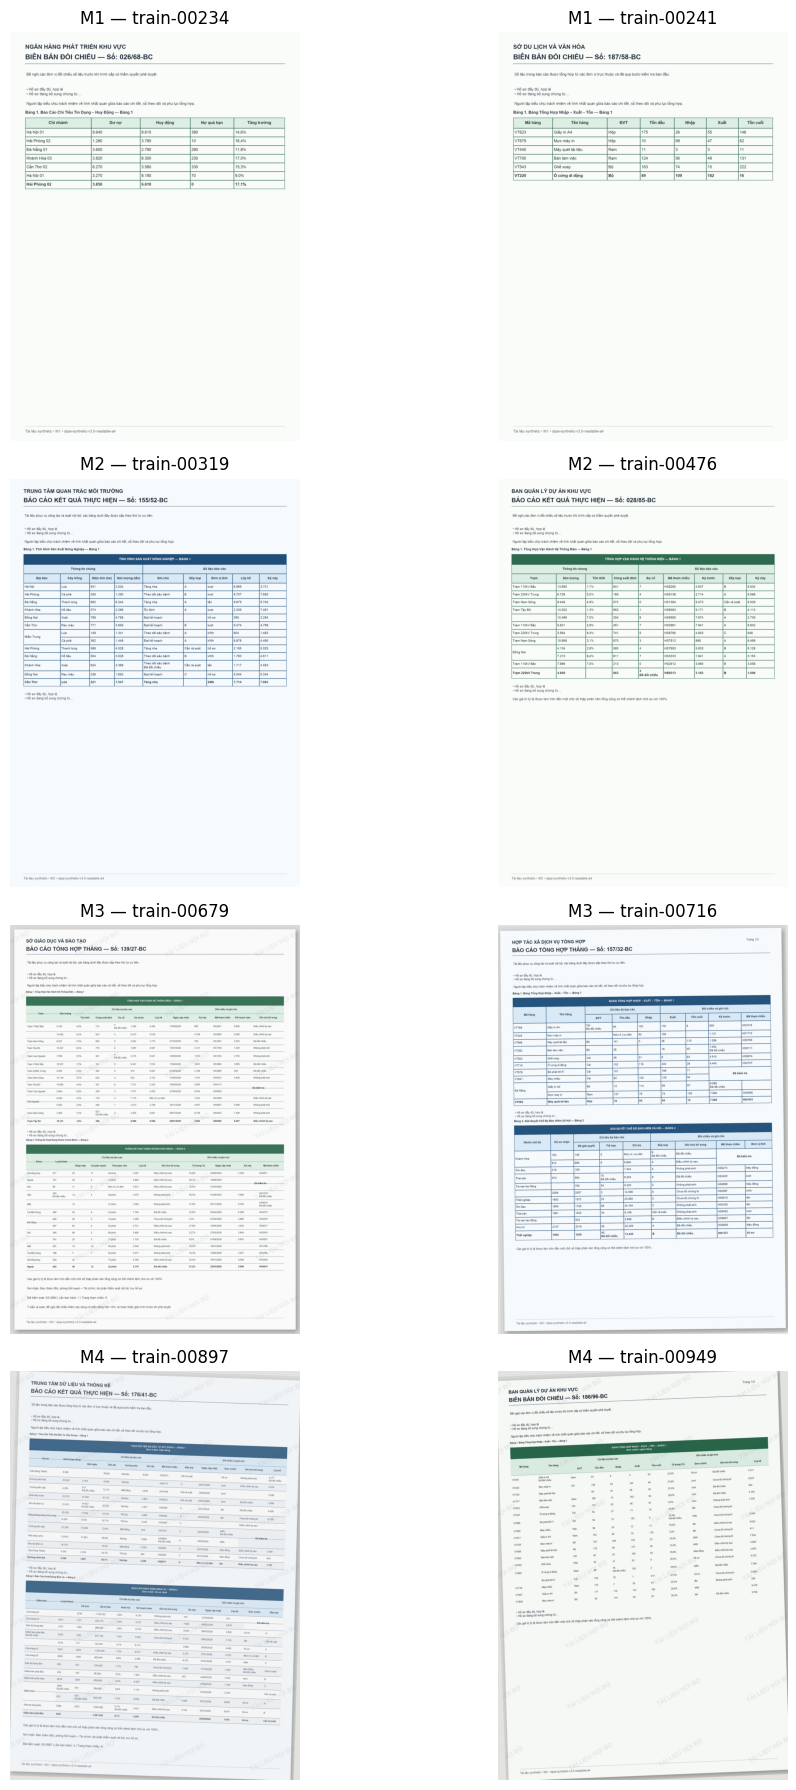

,doc_id,difficulty,image_path,label_path
234,train-00234,M1,images/train-00234_p01.jpg,labels/train-00234.md
241,train-00241,M1,images/train-00241_p01.jpg,labels/train-00241.md
319,train-00319,M2,images/train-00319_p01.jpg,labels/train-00319.md
476,train-00476,M2,images/train-00476_p01.jpg,labels/train-00476.md
679,train-00679,M3,images/train-00679_p01.jpg,labels/train-00679.md
716,train-00716,M3,images/train-00716_p01.jpg,labels/train-00716.md
897,train-00897,M4,images/train-00897_p01.jpg,labels/train-00897.md
949,train-00949,M4,images/train-00949_p01.jpg,labels/train-00949.md


In [21]:
record_frame = pd.DataFrame([{
    'doc_id': record['id'], 'difficulty': record['difficulty'],
    'image_path': record['image_paths'][0], 'label_path': record['label_path'],
} for record in train_records])
examples = (record_frame.groupby('difficulty', group_keys=False)
            .sample(n=2, random_state=RANDOM_STATE)
            .sort_values(['difficulty', 'doc_id']))

fig, axes = plt.subplots(4, 2, figsize=(12, 18))
for axis, sample in zip(axes.ravel(), examples.itertuples(index=False)):
    image = cv2.imread(str(TRAIN_DIR / sample.image_path))
    axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axis.set_title(f'{sample.difficulty} — {sample.doc_id}')
    axis.axis('off')
plt.tight_layout(); plt.show()
display(examples)

## 2.4 EDA → Design Decisions

Chỉ hoàn thiện mục này **sau khi chạy và đọc các output phía trên**. Mỗi decision phải truy ngược được về evidence cụ thể.

EDA trả lời **sẽ làm gì và tại sao**; phần Solution trả lời **thực hiện cụ thể như thế nào**.

In [22]:
# Bảng nháp để điền sau khi quan sát output. Không điền decision trước evidence.
decision_template = pd.DataFrame([
    {'topic': topic, 'observation': '', 'evidence': '', 'insight': '',
     'impact_if_ignored': '', 'what_we_will_dso': '', 'limitation': ''}
    for topic in [
        'Scope M1/M2',
        'Table count and page layout',
        'Rows and columns',
        'Border and image quality',
        'Horizontal and vertical merge',
        'Multiline content',
        'Bold formatting',
        'Cross-page tables',
    ]
])
display(decision_template)

,topic,observation,evidence,insight,impact_if_ignored,what_we_will_dso,limitation
0,Scope M1/M2,,,,,,
1,Table count and page layout,,,,,,
2,Rows and columns,,,,,,
3,Border and image quality,,,,,,
4,Horizontal and vertical merge,,,,,,
5,Multiline content,,,,,,
6,Bold formatting,,,,,,
7,Cross-page tables,,,,,,
